In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
filtered = pd.read_csv('eedi3_binnbiased_[155]_FILTERED_on_163_multiSeed_20251120_185811.csv')
unfiltered = pd.read_csv('eedi3_binnbiased_[155]_UNFILTERED_on_163_multiSeed_20251120_185912.csv')
# FILTERING BY PEOPLE WITH SUBJECT ID = 155 - 665 train, 214 valid, 215 test
# Parse comma-separated IDs
filtered['q_ids'] = filtered['sampled_q_ids'].str.split(',')
filtered['subj_ids'] = filtered['sampled_subject_ids'].str.split(',')
unfiltered['q_ids'] = unfiltered['sampled_q_ids'].str.split(',')
unfiltered['subj_ids'] = unfiltered['sampled_subject_ids'].str.split(',')

In [3]:
unfiltered.head()

,user_id,seed,sampled_q_ids,sampled_subject_ids,student_total_questions,q_ids,subj_ids
0,3507,100,"683,677,811,638,770,30,749,794,184,474","127,156,3,154,129,21,3,39,36,3",531,"[683, 677, 811, 638, 770, 30, 749, 794, 184, 474]","[127, 156, 3, 154, 129, 21, 3, 39, 36, 3]"
1,5784,100,"683,452,867,791,122,199,690,539,383,813","127,146,155,189,36,155,219,148,189,154",490,"[683, 452, 867, 791, 122, 199, 690, 539, 383, ...","[127, 146, 155, 189, 36, 155, 219, 148, 189, 154]"
2,5424,100,"683,677,811,396,731,451,922,312,184,134","127,156,3,267,219,163,154,148,36,155",535,"[683, 677, 811, 396, 731, 451, 922, 312, 184, ...","[127, 156, 3, 267, 219, 163, 154, 148, 36, 155]"
3,5481,100,"683,677,749,819,30,605,79,76,438,474","127,156,3,3,21,155,155,36,3,3",553,"[683, 677, 749, 819, 30, 605, 79, 76, 438, 474]","[127, 156, 3, 3, 21, 155, 155, 36, 3, 3]"
4,4511,100,"683,452,791,143,363,884,466,359,354,700","127,146,189,155,128,44,42,267,202,219",612,"[683, 452, 791, 143, 363, 884, 466, 359, 354, ...","[127, 146, 189, 155, 128, 44, 42, 267, 202, 219]"


In [4]:
all_subj_filtered = [s for subj_list in filtered['subj_ids'] for s in subj_list]
all_subj_unfiltered = [s for subj_list in unfiltered['subj_ids'] for s in subj_list]

subj_counts_f = pd.Series(all_subj_filtered).value_counts()
subj_counts_u = pd.Series(all_subj_unfiltered).value_counts()

comparison = pd.DataFrame({
    'Filtered': subj_counts_f,
    'Unfiltered': subj_counts_u
}).fillna(0).astype(int)
comparison['Difference'] = abs(comparison['Filtered'] - comparison['Unfiltered'])
comparison2 = comparison.sort_values('Difference', ascending=False)
print(comparison.head(20))
print("="*40)
print(comparison2.head(20))

     Filtered  Unfiltered  Difference
114         0          35          35
117        10           0          10
126        60         193         133
127       100        2087        1987
128         0         348         348
129         0         579         579
146         0         909         909
148         0        1164        1164
151         0         132         132
153         0         110         110
154         0         681         681
155     19530        3908       15622
156        70        1584        1514
163         0         131         131
164         0          89          89
165         0          46          46
168        10           0          10
169        40          57          17
170        10           0          10
173         0          60          60
     Filtered  Unfiltered  Difference
155     19530        3908       15622
3          40        2507        2467
127       100        2087        1987
156        70        1584        1514
148         

In [5]:
# 2. Per-student overlap
overlaps = []
for _, f_row in filtered.iterrows():
    u_row = unfiltered[unfiltered['user_id'] == f_row['user_id']]
    if not u_row.empty:
        u_row = u_row.iloc[0]
        
        q_f = set(f_row['q_ids'])
        q_u = set(u_row['q_ids'])
        s_f = set(f_row['subj_ids'])
        s_u = set(u_row['subj_ids'])
        
        overlaps.append({
            'user_id': f_row['user_id'],
            'q_overlap': len(q_f & q_u),
            'q_overlap_pct': len(q_f & q_u) / len(q_f) * 100,
            's_overlap': len(s_f & s_u),
            's_overlap_pct': len(s_f & s_u) / len(s_f) * 100
        })

overlap_df = pd.DataFrame(overlaps)

print(f"Average Question Overlap: {overlap_df['q_overlap_pct'].mean():.1f}%")
print(f"Average Subject Overlap: {overlap_df['s_overlap_pct'].mean():.1f}%")
print(f"\nStudents analyzed: {len(overlap_df)}")


Average Question Overlap: 11.5%
Average Subject Overlap: 85.5%

Students analyzed: 2020


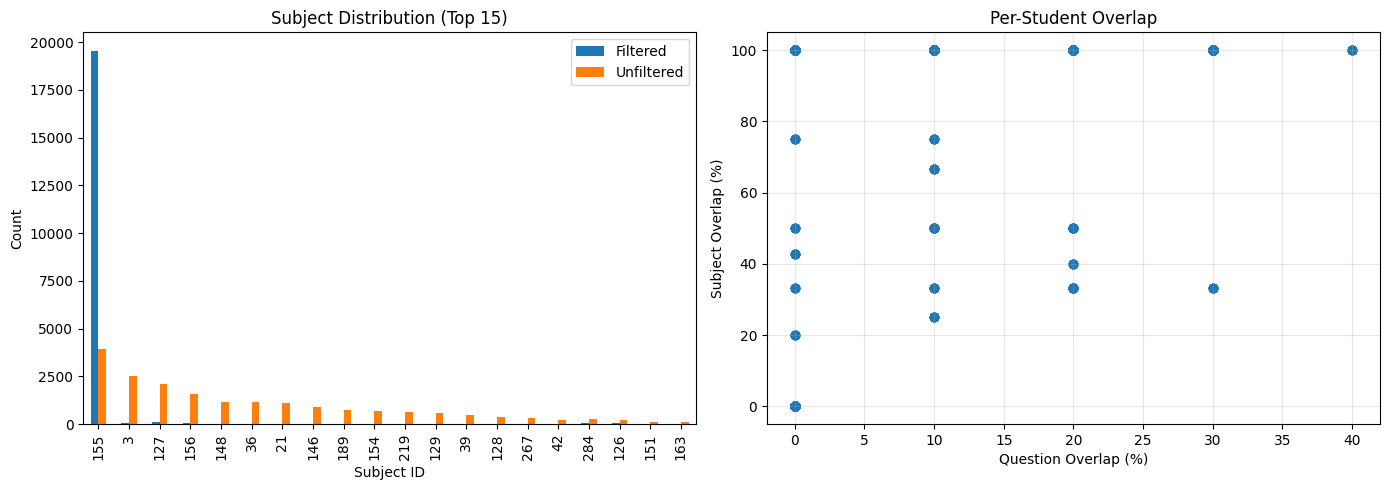

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subject distribution
top_subjects = comparison2.head(20)
top_subjects[['Filtered', 'Unfiltered']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Subject Distribution (Top 15)')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('Count')
axes[0].legend(['Filtered', 'Unfiltered'])

# Overlap scatter
axes[1].scatter(overlap_df['q_overlap_pct'], overlap_df['s_overlap_pct'], alpha=0.6)
axes[1].set_xlabel('Question Overlap (%)')
axes[1].set_ylabel('Subject Overlap (%)')
axes[1].set_title('Per-Student Overlap')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

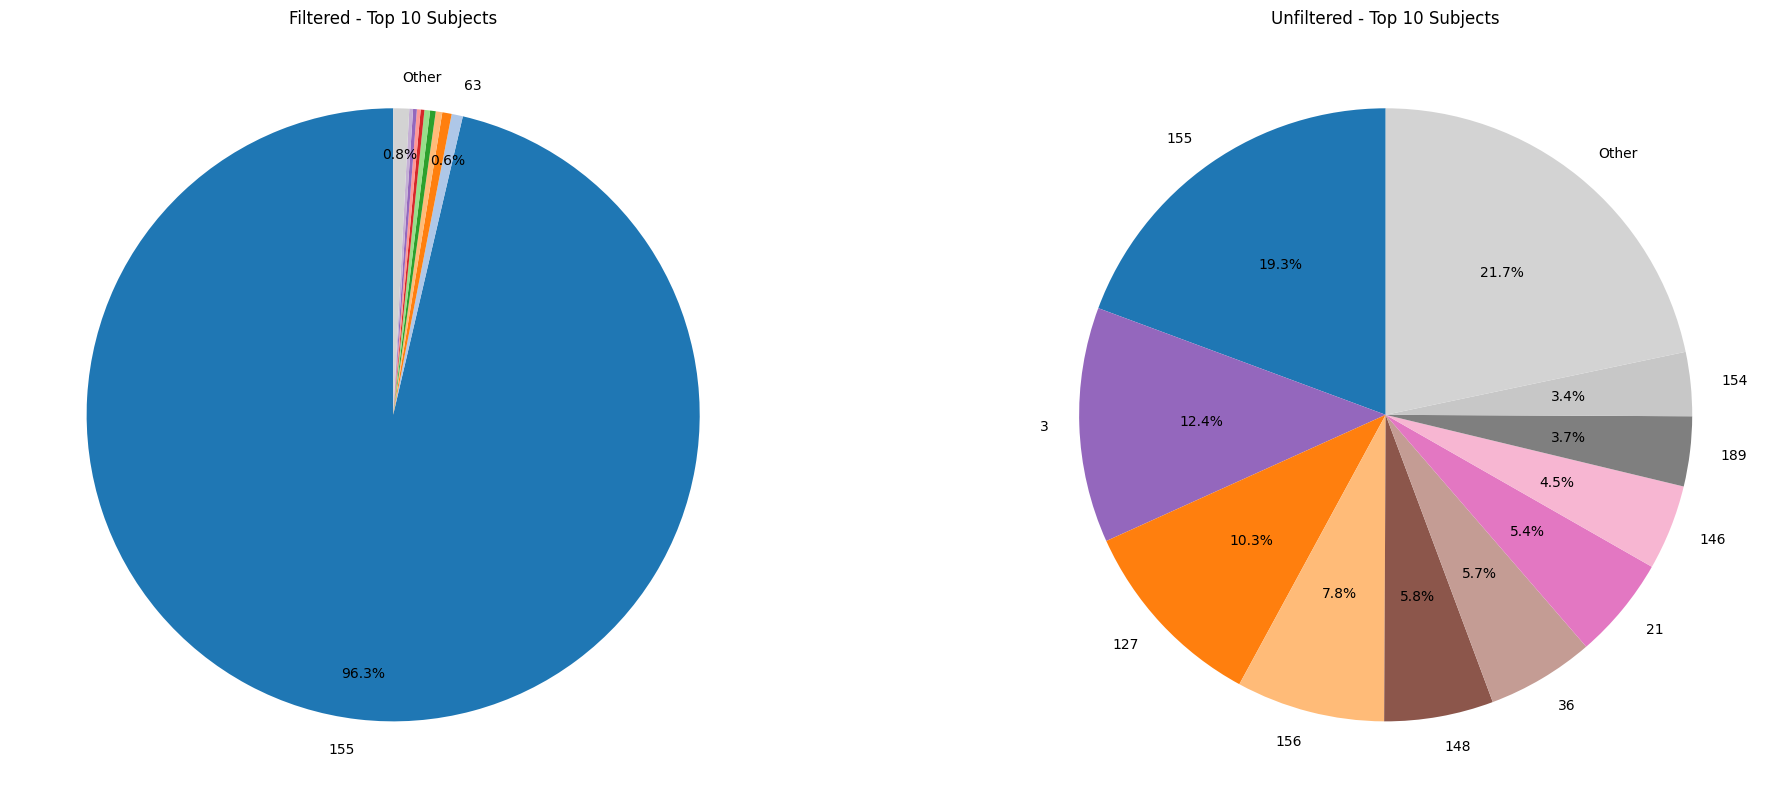

In [7]:
fig = plt.figure(figsize=(20, 16))
top_n = 10
# Get all unique subjects from both datasets and create color map
all_top_subjects = pd.concat([subj_counts_f.head(top_n), subj_counts_u.head(top_n)]).index.unique()
colors = plt.cm.tab20(range(len(all_top_subjects)))
color_map = {subj: colors[i] for i, subj in enumerate(all_top_subjects)}
color_map['Other'] = 'lightgray'

# Filtered pie
ax3 = plt.subplot(2, 2, 3)
top_filtered = subj_counts_f.head(top_n)
other_filtered = subj_counts_f.iloc[top_n:].sum()
pie_filtered = pd.concat([top_filtered, pd.Series({'Other': other_filtered})])
filtered_colors = [color_map.get(subj, 'gray') for subj in pie_filtered.index]

# Calculate percentages
percentages = pie_filtered / pie_filtered.sum() * 100

# Create custom labels - only show if >= 0.5%
labels = [label if pct >= 0.5 else '' for label, pct in zip(pie_filtered.index, percentages)]

# Custom autopct function - only show if >= 0.5%
def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 0.5 else ''

wedges, texts, autotexts = ax3.pie(
    pie_filtered, 
    labels=labels,  # Use filtered labels
    autopct=autopct_format,  # Use custom function
    startangle=90, 
    colors=filtered_colors,
    pctdistance=0.85,
    labeldistance=1.1,
)
        
ax3.set_title(f'Filtered - Top {top_n} Subjects')

# Unfiltered pie
ax4 = plt.subplot(2, 2, 4)
top_unfiltered = subj_counts_u.head(top_n)
other_unfiltered = subj_counts_u.iloc[top_n:].sum()
pie_unfiltered = pd.concat([top_unfiltered, pd.Series({'Other': other_unfiltered})])
unfiltered_colors = [color_map.get(subj, 'gray') for subj in pie_unfiltered.index]
ax4.pie(pie_unfiltered, labels=pie_unfiltered.index, autopct='%1.1f%%', startangle=90, colors=unfiltered_colors)
ax4.set_title(f'Unfiltered - Top {top_n} Subjects')

plt.tight_layout()
plt.show()

## Connecting with train_task_3_4 and q_id_to_subjects_mapping.csv

In [8]:
# Load the train task JSON file
with open('../data/train_task_3_4.json', 'r') as f:
    train_data = json.load(f)

# Load the question ID to subjects mapping
q_id_mapping = pd.read_csv('../data/q_id_to_subjects_mapping.csv')

# Create a dictionary mapping student_id to all their question IDs
student_to_questions = {}
for entry in train_data:
    student_id = entry['user_id']
    
    # Handle question_id - could be a list string or a single value
    question_id = entry['q_ids']
    if isinstance(question_id, str) and question_id.startswith('['):
        # It's a stringified list, parse it
        question_ids = json.loads(question_id)
    elif isinstance(question_id, list):
        question_ids = question_id
    else:
        question_ids = [question_id]
    
    if student_id not in student_to_questions:
        student_to_questions[student_id] = []
    student_to_questions[student_id].extend([str(qid) for qid in question_ids])

# Create a dictionary mapping question_id to subject_ids
q_id_to_subjects = {}
for _, row in q_id_mapping.iterrows():
    q_id = str(row['q_id'])
    
    # Handle subject_id - could be a list string or a single value
    subject_id = row['subject_ids']
    if isinstance(subject_id, str) and subject_id.startswith('['):
        # It's a stringified list, parse it
        subject_ids = json.loads(subject_id)
    elif isinstance(subject_id, list):
        subject_ids = subject_id
    else:
        subject_ids = [subject_id]
    
    if q_id not in q_id_to_subjects:
        q_id_to_subjects[q_id] = []
    q_id_to_subjects[q_id].extend([str(sid) for sid in subject_ids])



In [9]:
# Function to get all available questions and subjects for a student
def get_available_data(student_id):
    if student_id not in student_to_questions:
        return [], []
    
    all_q_ids = student_to_questions[student_id]
    all_subj_ids = []
    
    for q_id in all_q_ids:
        if q_id in q_id_to_subjects:
            all_subj_ids.append(q_id_to_subjects[q_id])
        else:
            all_subj_ids.append([])  # Empty list if no subjects found for this question
    
    return all_q_ids, all_subj_ids

# Add columns to filtered dataframe (using user_id, not SubjectID)
filtered['available_q_ids'] = filtered['user_id'].apply(
    lambda uid: get_available_data(uid)[0]
)
filtered['available_subject_ids'] = filtered['user_id'].apply(
    lambda uid: get_available_data(uid)[1]
)

# Add columns to unfiltered dataframe
unfiltered['available_q_ids'] = unfiltered['user_id'].apply(
    lambda uid: get_available_data(uid)[0]
)
unfiltered['available_subject_ids'] = unfiltered['user_id'].apply(
    lambda uid: get_available_data(uid)[1]
)

In [10]:
filtered.iloc[0]

user_id                                                                 3507
seed                                                                     100
sampled_q_ids                        134,209,676,867,764,461,337,234,372,637
sampled_subject_ids                  155,155,155,155,155,155,155,155,155,155
student_total_questions                                                  531
q_ids                      [134, 209, 676, 867, 764, 461, 337, 234, 372, ...
subj_ids                   [155, 155, 155, 155, 155, 155, 155, 155, 155, ...
available_q_ids            [809, 941, 209, 185, 635, 463, 813, 786, 638, ...
available_subject_ids      [[155], [154], [155], [154], [154], [155], [15...
Name: 0, dtype: object

In [11]:
len(filtered.iloc[0]["available_q_ids"])
len(filtered.iloc[0]["available_subject_ids"])

531

In [12]:
# filtered.iloc[0]["available_subject_ids"]

In [13]:
unfiltered["num_subjects"] = unfiltered["sampled_subject_ids"].str.split(",").apply(set).apply(len)

In [14]:
filtered["num_subjects"] = filtered["sampled_subject_ids"].str.split(",").apply(set).apply(len)

(0.0, 1.0)

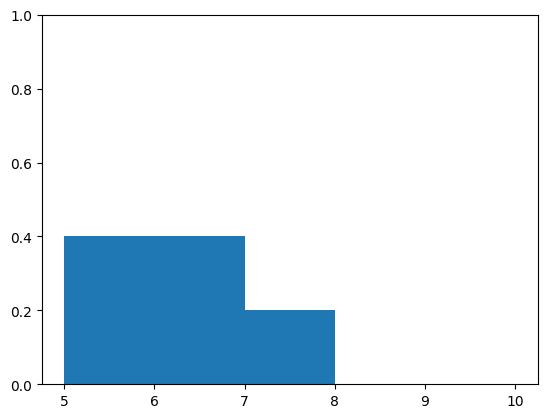

In [15]:
plt.hist(filtered["num_subjects"], density = True, bins=range(5,11))
plt.ylim([0,1])

(0.0, 1.0)

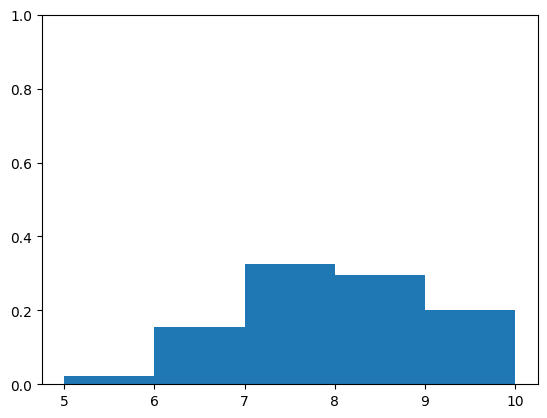

In [16]:
plt.hist(unfiltered["num_subjects"], density = True, bins=range(5,11))
plt.ylim([0,1])

In [17]:
filtered["sampled_q_ids"].str.split(",").apply(
    lambda x: x[0]
).value_counts()

sampled_q_ids
134    1960
676      40
360      10
61       10
Name: count, dtype: int64

In [18]:
unfiltered["sampled_q_ids"].str.split(",").apply(
    lambda x: x[0]
).value_counts()

sampled_q_ids
683    1640
452     310
96       60
407      10
Name: count, dtype: int64